## What is a Vector?

A **vector** is simply a list (array) of numbers that represents something in multi-dimensional space.

```
[0.23, -0.11, 0.87, 0.45, ...]
```

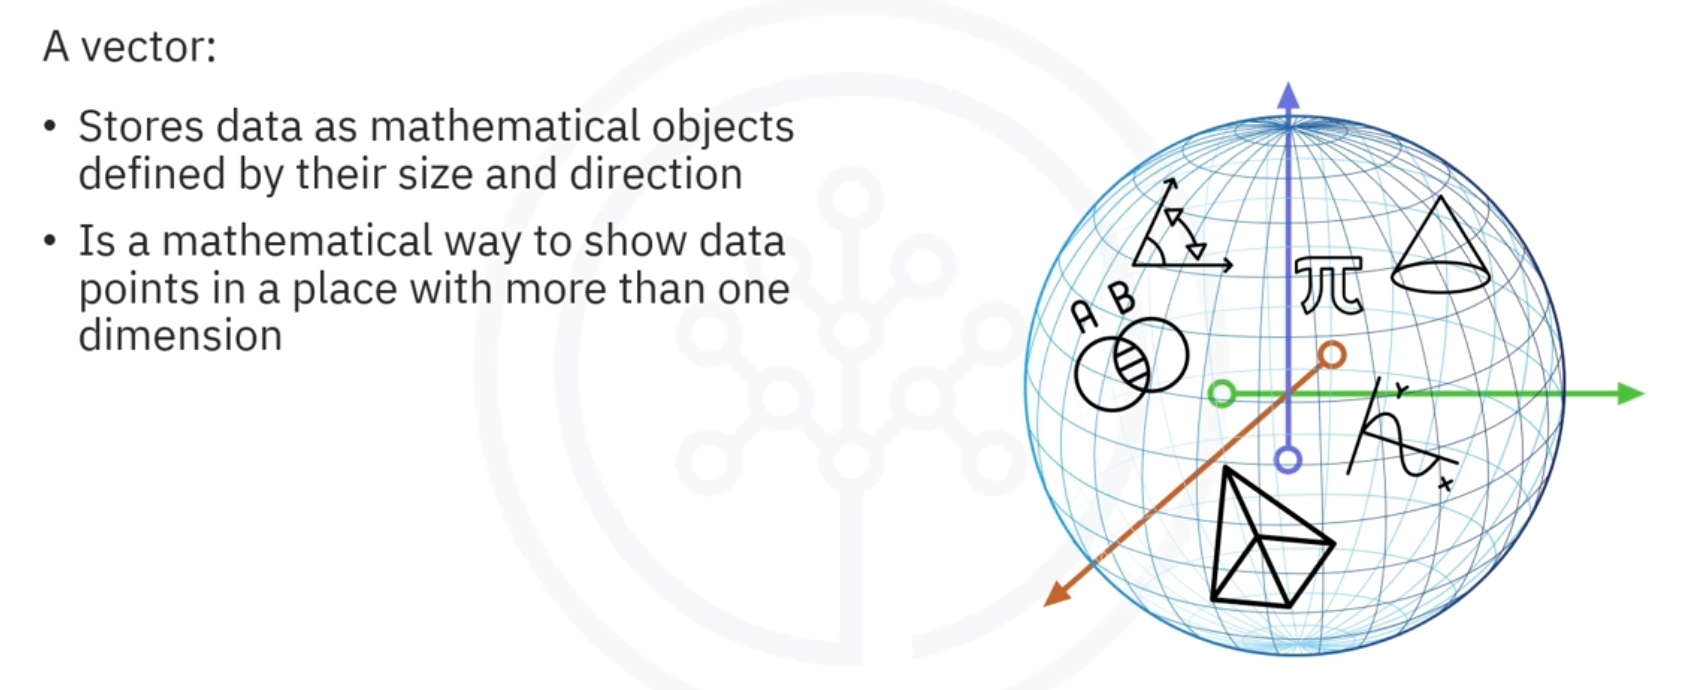

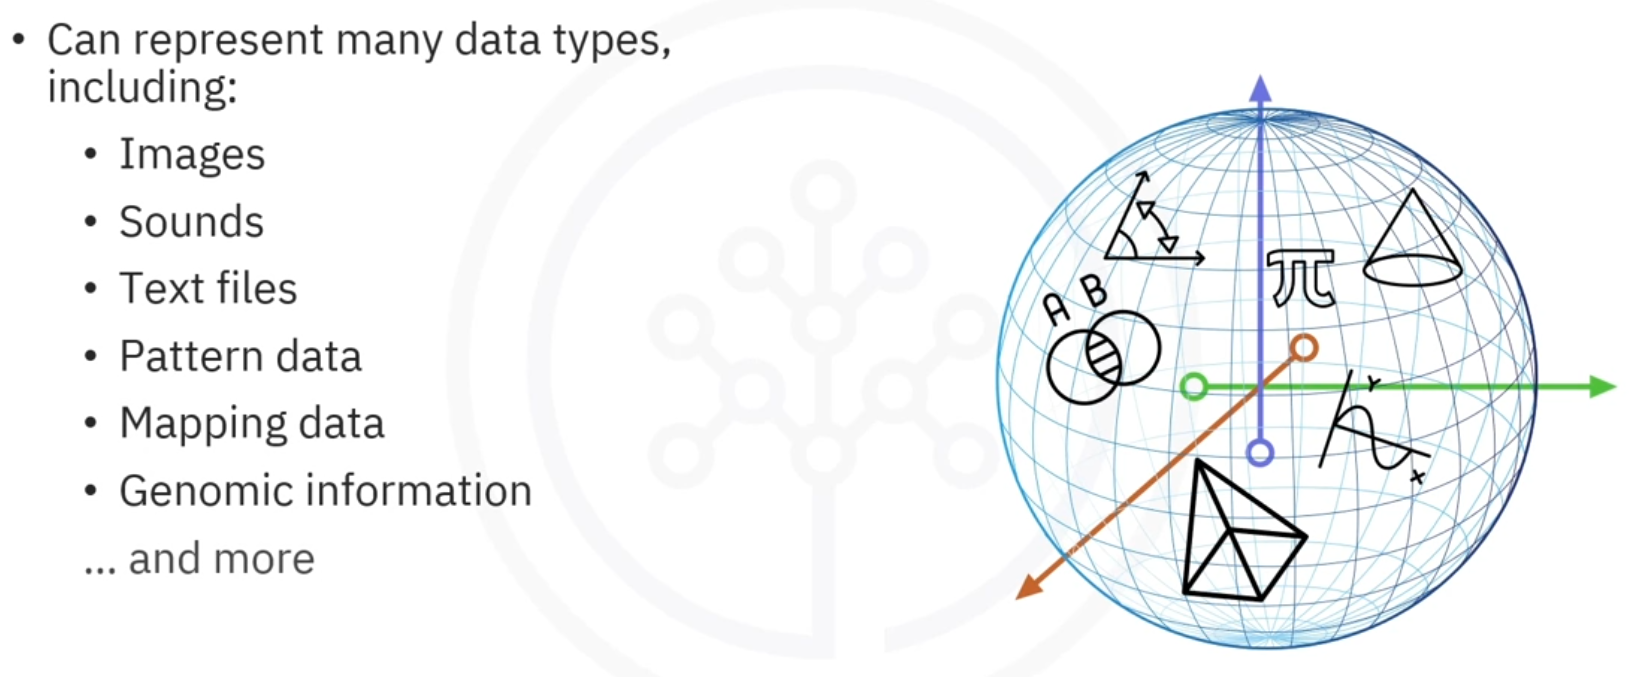

In the context of ML/AI, a vector is usually an **embedding** — a numerical representation of unstructured data (text, image, audio) generated by a machine learning model.

A vector for a token is a learned numerical representation capturing patterns/meaning about that word/token. Each number isn't some arbitrary label, it's a coordinate that the model learned during training so that similar meanings land near each other in space.

- Each number in the vector is a "dimension"
- Embeddings are typically high-dimensional (e.g., 384, 768, 1536 dimensions depending on the model)
- Data points that are **semantically similar** end up **close together** in this vector space, and dissimilar ones end up far apart

**Example:**
- "king" and "queen" → vectors close to each other
- "king" and "banana" → vectors far apart

This closeness is measured using **distance/similarity metrics** (cosine similarity, Euclidean distance, dot product) — *vector database search is fundamentally "find the nearest vectors."*

### Vector is a dimension? what that means?

Vector is a dimension - that's literally what it is, geometrically — just extended beyond what you can physically visualize.

#### Start small, something you already know from math:

- A single number → a point on a **1D line**
- Two numbers `[x, y]` → a point on a **2D plane** (like a graph)
- Three numbers `[x, y, z]` → a point in **3D space** (like a room)

In each case, **the count of numbers = the count of dimensions** needed to place that point in space. `[x, y, z]` needs 3 axes to plot — so it's a 3-dimensional vector.

#### Now scale that up

A 768-number vector `[0.23, -0.11, 0.87, ..., 0.45]` is a point in a **768-dimensional space**. You can't draw it or visualize it (human brains max out at 3D intuition), but mathematically it's the exact same idea as the `[x, y, z]` example — just 768 axes instead of 3.

So:
- **"Dimension"** = one axis of that space = one number/slot in the vector
- **The vector as a whole** = one point's *coordinates* in that 768-axis space
- **What that point represents** = the meaning/pattern of the token, learned by the model

#### Why this framing matters for vector databases specifically

This is exactly why vector DBs talk about **"nearest neighbor search"** — it's not a metaphor, it's literal geometry. Two tokens with similar meaning end up as two points that are *physically close* to each other in that 768-dimensional space, and "search" means finding which points are closest to your query point — same concept as finding the nearest city on a 2D map, just in way more axes.

---

## What is a Vector Database?

A **vector database** is a database purpose-built to **store, index, and search vectors (embeddings) efficiently**, based on similarity rather than exact matches.

Traditional databases (SQL, NoSQL) are built for **exact match** or **range queries**:
```sql
SELECT * FROM users WHERE age = 25
```

Vector databases are built for **similarity queries**:
```
"Find me the 5 vectors most similar to this query vector"
```

Core operations a vector DB supports:
- **Store** — insert embeddings (usually alongside the original text/metadata)
- **Index** — organize vectors so search doesn't have to compare against every single vector (brute-force doesn't scale)
- **Query/Search** — given a query vector, retrieve the top-k nearest vectors

Examples: **ChromaDB**, Pinecone, Weaviate, Milvus, FAISS (technically a library, not a full DB), Qdrant.

---

#### Importance of Vector Databases

**1. Traditional databases can't do semantic search**
- SQL/NoSQL match on exact keywords or structured fields
- They have no concept of "meaning" — they can't tell that "car" and "automobile" are related

**2. Enables semantic/similarity search**
- Search by *meaning*, not exact keyword
- Powers use cases like: "find documents similar to this one," "find similar images," "find similar products"

**3. Backbone of RAG (Retrieval-Augmented Generation)**
- LLMs have a fixed knowledge cutoff and limited context window
- Vector DBs let you store your own documents as embeddings, then retrieve only the most *relevant* chunks to feed into the LLM's prompt at query time — instead of dumping your entire knowledge base into context
- This is the core mechanism that makes RAG work at all

**4. Scale**
- Brute-force(a trial-and-error method that tries every single possible option one by one until the right answer or password is found) comparing a query vector against millions of stored vectors is too slow
- Vector DBs use **approximate nearest neighbor (ANN)** indexing algorithms (e.g., HNSW) to make this fast even at massive scale.

**5. Beyond text**
- Same idea applies to images, audio, video — anything that can be embedded into a vector, similarity search on it becomes possible

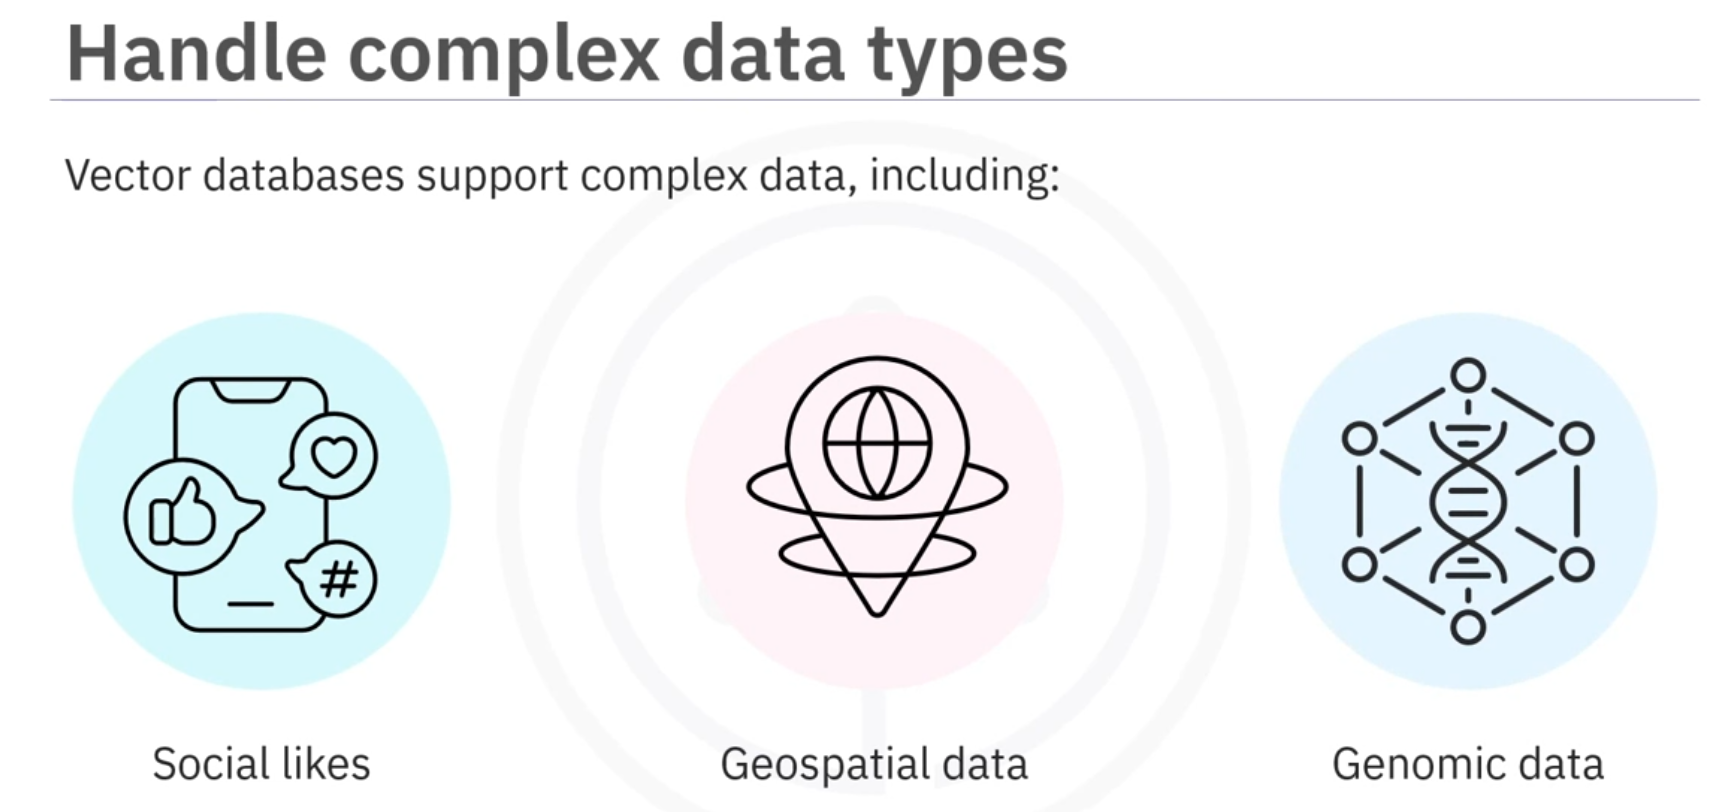

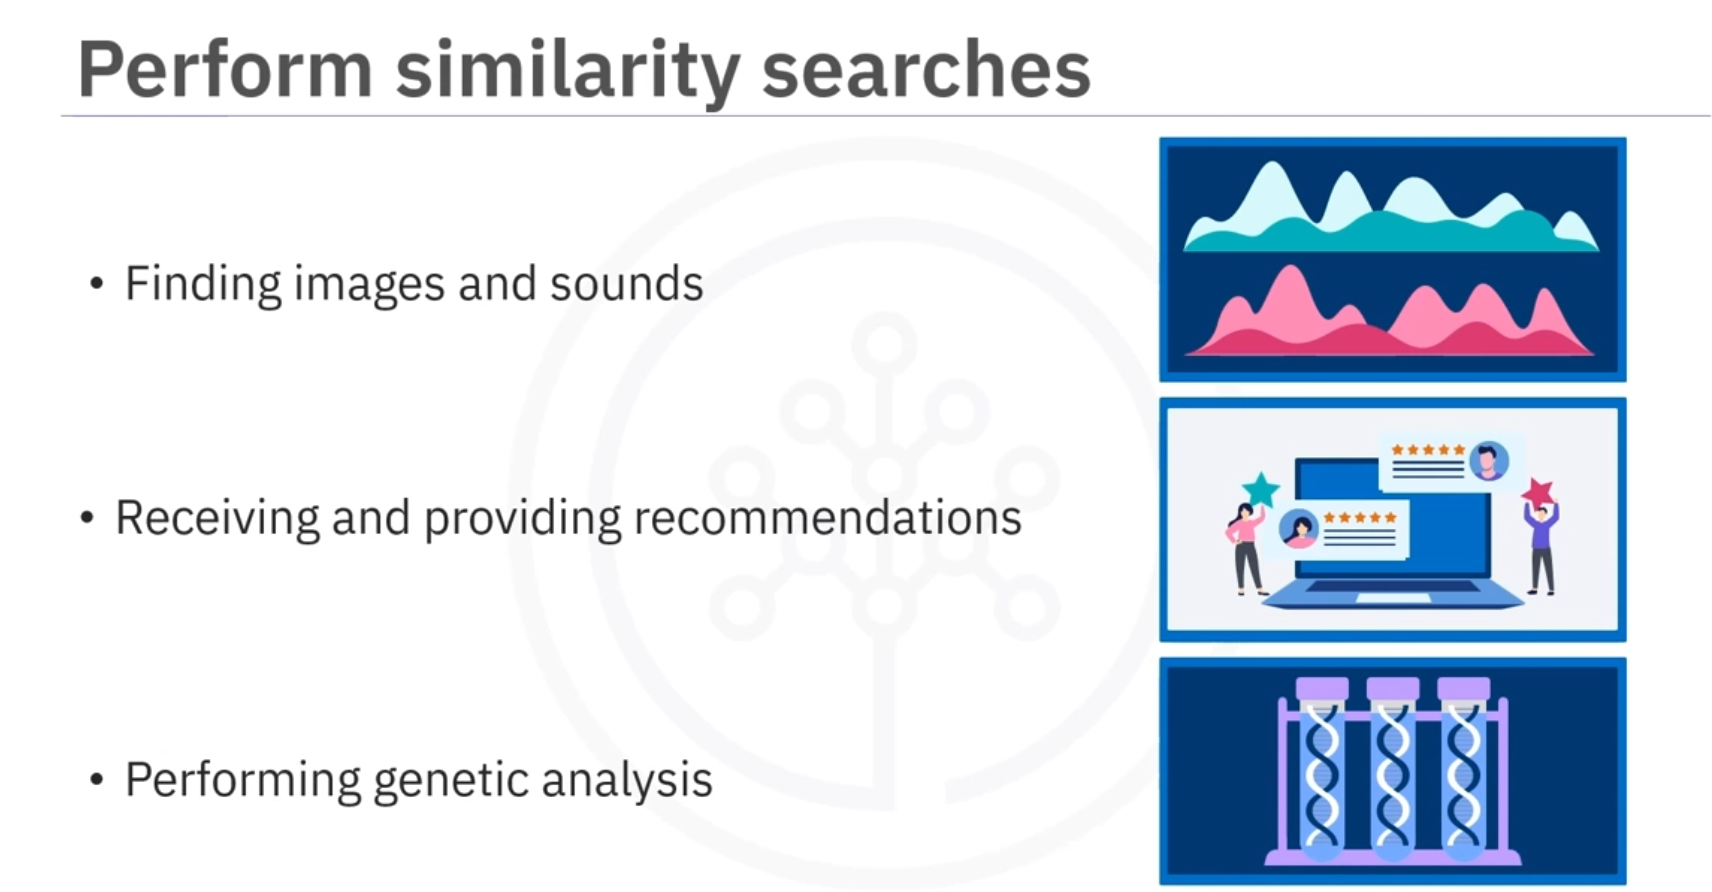

## Vector Databases VS Traditional Databases :-

A vector database is a specialized database designed to store and query vectorized data rapidly. Unlike conventional databases, which organize data in tables, a vector database represents data as vectors in a multi-dimensional space. These vectors encapsulate essential attributes of the items they represent, making vector databases ideal for tasks requiring similarity searches, nearest neighbor queries, and assessing distances or similarities between vectors.

#### Vector databases data storage

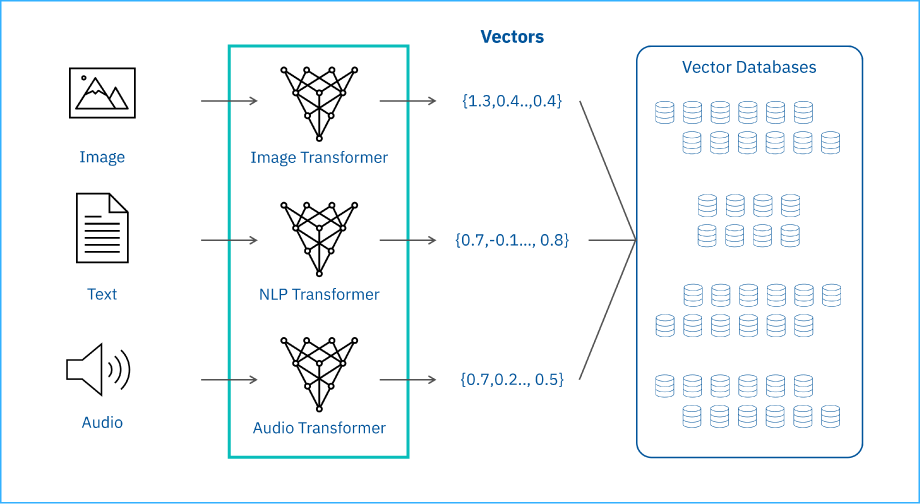

# Vector Databases VS Traditional Databases

#### The Core Difference

Traditional databases are built to store and retrieve **structured, exact data**. Vector databases are built to store and retrieve **unstructured data based on similarity/meaning**.

## Comparison

| Aspect | Traditional Database (SQL/NoSQL) | Vector Database |
|---|---|---|
| **Data stored** | Structured rows/columns, key-value pairs, documents | High-dimensional numerical vectors (embeddings) |
| **Query type** | Exact match, filters, range queries | Similarity/nearest-neighbor search |
| **Example query** | `SELECT * FROM users WHERE age = 25` | "Find the 5 most similar vectors to this one" |
| **Matching logic** | Boolean — matches exactly or doesn't | Distance/similarity-based — ranked by closeness |
| **Best suited for** | Transactional data, structured records (orders, users, inventory) | Unstructured data — text, images, audio, semantic search |
| **Underlying data structure** | B-trees, hash indexes | ANN (Approximate Nearest Neighbor) indexes, e.g., HNSW |
| **"Search" means** | Does this row match my condition? | Which points are geometrically closest to my query point? |

**Not Necessarily a Replacement**

In practice, vector DBs and traditional DBs often work **together** — e.g., a traditional DB holds structured metadata (user info, timestamps, categories) while a vector DB holds embeddings for semantic search, and many modern vector DBs (like ChromaDB) let you attach metadata to vectors and filter on both simultaneously.

#### Vector Library:

A vector library is just a **code library/package** (like `faiss`, `annoy`, `hnswlib`) that gives you functions to do **fast similarity search** on a bunch of vectors. That's it — it's not a database, it's a toolkit you import into your Python script.

You give it a bunch of vectors, it builds an in-memory index, and you can ask "give me the top-k closest vectors to this query vector."

#### CRUD:

**CRUD** = Create, Read, Update, Delete — the four basic operations any proper database should support on individual records.

With a vector **library** like FAISS:
- You build the index once from your vectors (kind of like "Create," but in bulk)
- You can search/read from it ✅
- But if you want to **update** one vector (say, the embedding changed) or **delete** one entry — there's no clean built-in way to do that on the fly. In practice, you often have to **rebuild the whole index from scratch** to reflect changes
- It also lives **in-memory** — if your Python process restarts, that index is gone unless you manually saved/reloaded it yourself

With a vector **database** like ChromaDB:
- You can `add()`, `get()`, `update()`, `delete()` individual entries directly, live, without rebuilding everything
- It persists to disk automatically — restart your app, data's still there
- This is why it's called a proper "database" and FAISS is called a "library"

**In short: FAISS = fast search algorithm you manage yourself. ChromaDB = fast search algorithm + database management (CRUD, persistence, metadata) done for you.**

#### Relational Database:

**Relational database** = SQL-style database** (PostgreSQL, MySQL, SQLite, Oracle). Data lives in tables with rows/columns, and tables relate to each other via keys (that's why it's called "relational").

## How Vector DB works with RAG :-

Vector DB is specifically for **your own data** — documents, PDFs, notes, a company's FAQ, whatever you want the LLM to answer questions about accurately.

#### The actual flow — step by step
1. **You have a document** (PDF, text file, whatever)
2. **You split it into chunks** — small pieces, like paragraphs (this is called "chunking")
3. **Each chunk gets converted into a vector** — a list of numbers representing its meaning — this is called an **embedding**
4. **These embeddings get stored in the vector database** (ChromaDB) — this is the actual "storage" step
5. **User asks a question** → the question itself also gets embedded (same process)
6. **Vector DB searches for chunks whose embeddings are closest in meaning** to the question's embedding
7. **Those relevant chunks get pulled out and stuffed into the prompt** sent to the LLM, along with the user's question
8. **LLM answers using that specific context** — instead of guessing from its training data, it now has your actual document content in front of it

That entire pipeline — steps 1 through 8 — is what "RAG" means: **Retrieval-Augmented Generation.**

#### Who does what
- **Embedding** (step 3) — done by an embedding model (a small, separate model, often free/cheap, like OpenAI's or Google's embedding API, or a local Hugging Face model)
- **Storing + searching embeddings** (step 4, 6) — this is ChromaDB's job specifically
- **Orchestrating the whole pipeline** (chunking → embedding → storing → retrieving → prompting the LLM) — this is what **LlamaIndex** does. It's the glue that calls the embedding model, talks to ChromaDB, and formats everything for the LLM, so you don't hand-code every step yourself.
- **LangChain** — does the same kind of orchestration, but more general-purpose. Beyond just RAG, it also handles things like: remembering earlier turns in a conversation, calling external tools/APIs, multi-step decision logic. Overlaps with LlamaIndex for RAG specifically, but has a much wider scope beyond it.

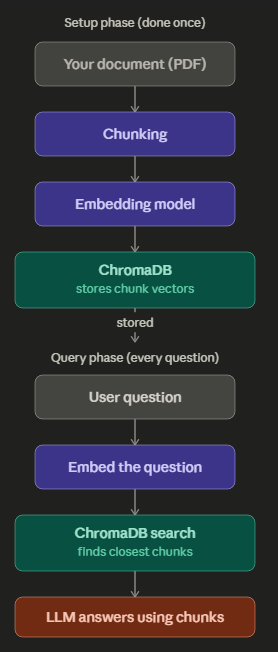

## Vector Database Types

**Firstly, what is a Vendor?**

Vendor = the company or project that builds/provides that specific database software.

So "FAISS is a vendor" just means "FAISS is the tool/product, made by Facebook AI" — same idea as saying "MySQL is a vendor" (Oracle) or "MongoDB is a vendor" (MongoDB Inc.).

#### Categorization by Storage Architecture

| Type | How it works | Tradeoff | Best for | Anchor example |
|---|---|---|---|---|
| **In-memory** | Vectors stored directly in RAM | Very fast read/write, but limited by RAM size, not persistent by default | Real-time apps, recommendation systems | RedisAI |
| **Disk-based** | Vectors stored on disk with indexing/compression | Handles datasets too big for RAM, slightly slower than in-memory | Large datasets exceeding memory | Annoy |
| **Distributed** | Vector data spread across multiple nodes/servers | Horizontal scalability + fault tolerance, but more infra complexity | Massive datasets, high-throughput systems | FAISS (can run distributed) |
| **Graph-based** | Vectors stored as node/edge attributes in a graph structure | Captures relationships between entities, not just similarity | Social networks, knowledge graphs, recommendation via relationships | Neo4j |
| **Time-series** | Vectors tied to timestamped data | Optimized for temporal pattern/anomaly detection | IoT, monitoring, forecasting | InfluxDB |

---

### Dedicated Vector Databases vs. Vector-Search-Capable Databases

#### Dedicated Vector Databases

- **Built from the ground up** for vector storage/search as the primary purpose
- Use specialized indexing structures (inverted indexes, product quantization, **LSH — locality sensitive hashing**) purely optimized for high-dimensional similarity search
- Prioritize speed + scalability for vector operations specifically
- Examples: **FAISS, Annoy, Milvus** — and by extension, **ChromaDB**

#### Databases That Support Vector Search (bolt-on)

- These are **general-purpose databases** (relational, document, etc.) that added vector search as a *feature*, not their core design
- Store vectors as blobs/arrays/custom types, with plugins enabling similarity search alongside their normal querying
- Examples: **PostgreSQL (via pgvector), Elasticsearch, MongoDB, MySQL**
- **Tradeoff:** convenient if you're already using that database for other data (no new infra to manage), but generally **not as fast/optimized** for pure vector workloads as a dedicated vector DB

**Why this matters practically:** when you're deciding on a vector DB for a real project later, this is the actual decision you'll face — "do I add pgvector to my existing Postgres, or bring in a dedicated vector DB like ChromaDB/Pinecone?" That tradeoff (convenience/no new infra vs. raw performance) is the real-world question this section is actually teaching, buried under a pile of vendor names.

## Applications of Vector Databases

Vector databases aren't limited to text/RAG — the same "embed → store → search by similarity" mechanism applies to almost any type of data. Companies use this across images, recommendations, location data, and social platforms. There are many more real-world applications beyond these, but here are the main ones:

#### 1. Image & Video Analysis

- Images/videos get converted into embeddings capturing their visual features
- Similarity search on these embeddings enables reverse image search, video content summarization, and "similar image" suggestions
- **Example:** a photo app embeds a newly added photo, compares it against existing ones, and auto-suggests grouping/tagging similar photos into albums

#### 2. Recommendation Systems

- Items (movies, products, etc.) get embedded as vectors capturing their characteristics
- Recommending = finding items whose vectors are closest to what a user already liked
- **Example:** a streaming service embeds movies; after you watch one, it recommends others with similar embeddings
- Cross-domain suggestions — combining embeddings from different data sources (viewing history + search behavior) — can further improve recommendation quality

#### 3. Geospatial / Location-Based Services

- GPS coordinates, addresses, and map data get indexed using spatial-optimized structures (R-tree, quadtree — different from the ANN indexes used for typical semantic search)
- Enables proximity search, fleet/vehicle routing, and location-based recommendations
- **Example:** a navigation app finds restaurants within a certain distance of your current location

#### 4. Social Media & Marketing Analytics

- User profiles/interests/behavior get embedded to represent preferences at scale
- Enables trend analysis, ad targeting, and personalization for large numbers of concurrent users
- **Example:** a platform tracks user interests (hobbies, clicks) as vectors, scaling infrastructure as its user base grows

#### Key Takeaway

Image/video, recommendations, and geospatial all use the exact same underlying mechanism like for text/RAG — embed something, store it, search by similarity. Only the domain changes; the core technique stays the same.

## Similarity Search

Good instinct to want to trim this — but heads up, **this one's actually worth keeping**, more than the last few sections. This isn't filler; "which distance metric to use" is a real decision you'll make in ChromaDB (it has a `metric` parameter), and it comes up in interviews too. I'll strip out all the geometric derivations/proofs (the "why cosine formula works" math) and keep only what's practically useful.

#### What is Similarity Search?

The process of finding items in a dataset that are most similar to a given query item. Powers recommendation systems, image/video retrieval, NLP (finding similar documents/sentences), and biometrics (face recognition).

At its core: a **distance or similarity metric** quantifies how alike two vectors are. The right metric depends on your data and use case — this is the practical decision to focus on.

#### Distance vs Similarity

- **Distance metric** → bigger number = farther apart = less similar
- **Similarity metric** → bigger number = more similar
- These are often two sides of the same coin — you can usually convert one into the other with a simple formula (e.g., `cosine_distance = 1 - cosine_similarity`)

### Distance & Similarity Metrics

#### 1. L2 Distance (Euclidean Distance)

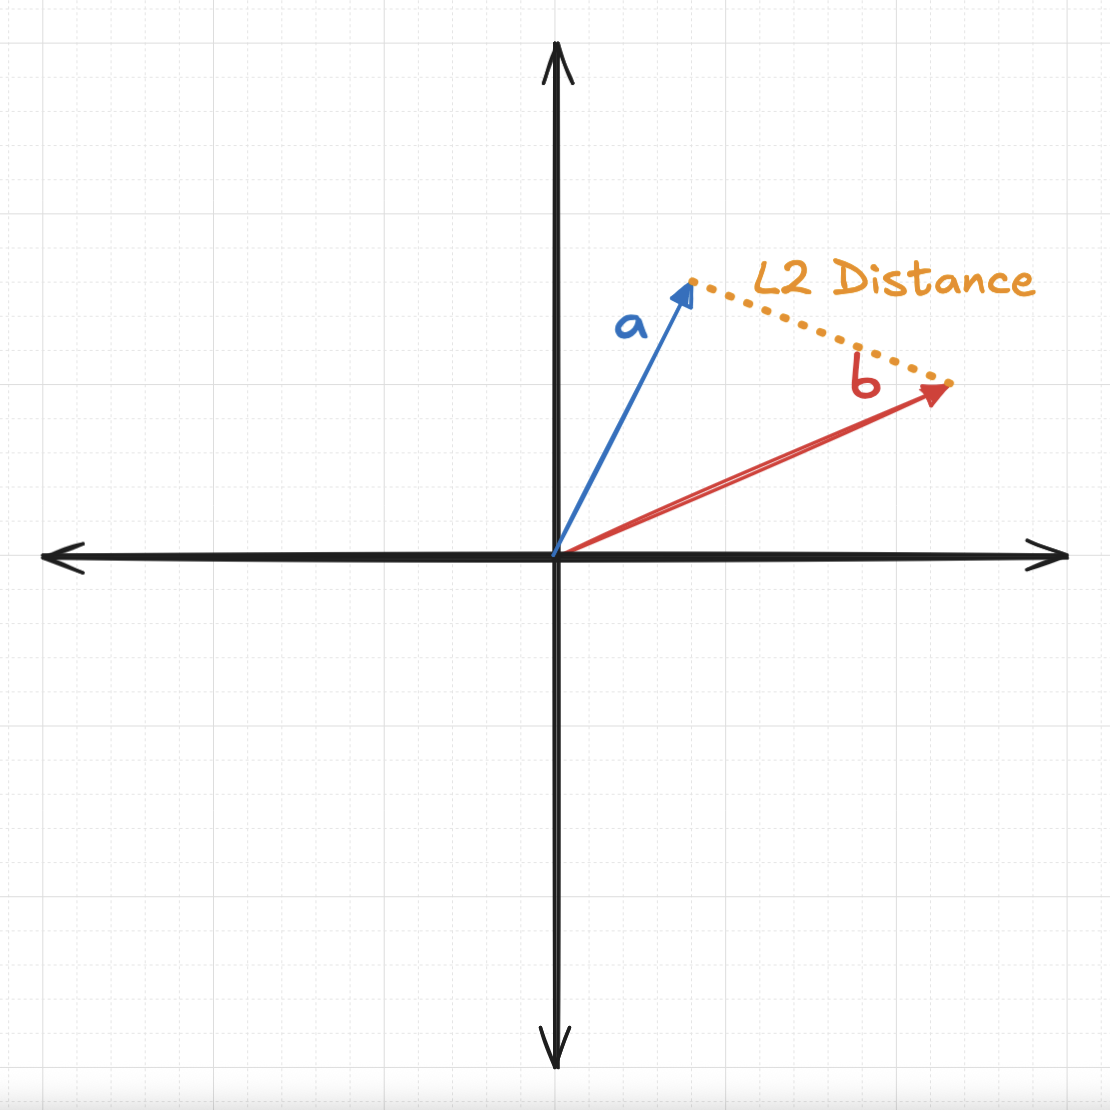

**What it measures:** straight-line distance between two vector points — literally the same distance formula from school geometry (Pythagorean theorem), just extended to more dimensions.

**Sensitive to:** both magnitude and direction.

**Best for:** spatial/geometric data — image analysis, computer vision, geographic/location data. Finding "closest point" in space.

**Downside:** suffers from the "curse of dimensionality" — gets less reliable/meaningful as the number of dimensions grows very large (which is exactly the situation with 768-dim text embeddings).

#### 2. Dot Product Similarity

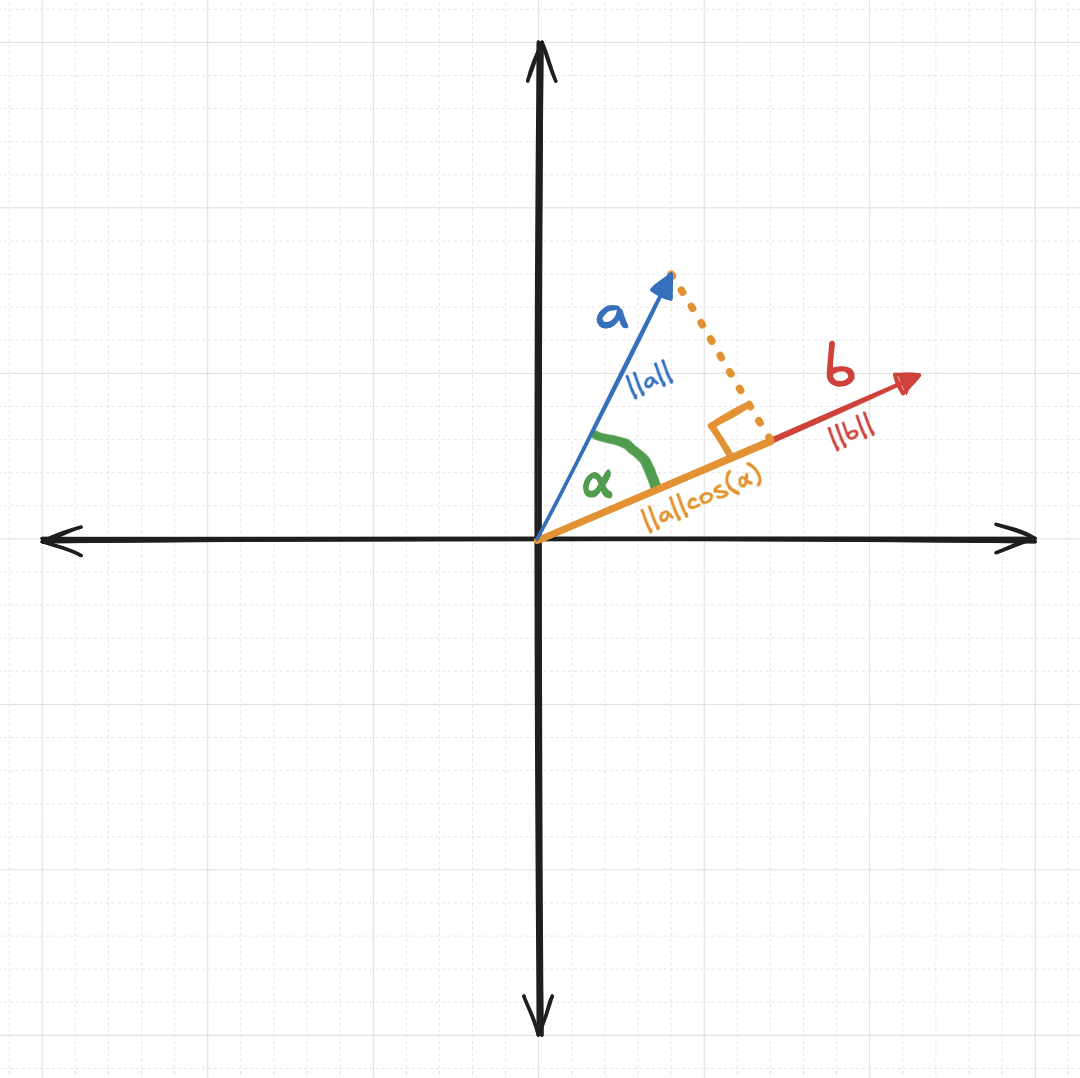

**What it measures:** a similarity score based on both the angle between vectors *and* their magnitudes.

**Sensitive to:** both magnitude and direction — larger vectors (longer length) can produce a larger dot product even if the angle/meaning is similar.

**Best for:** cases where **magnitude carries real meaning** — e.g., a recommendation system where vector direction = topic, but vector length = popularity/confidence. You'd want to recommend items that are both relevant *and* popular — dot product captures that combination.

**Efficient to compute** — commonly used inside neural networks/matrix operations.

#### 3. Cosine Similarity

**What it measures:** only the **angle** between two vectors — ignores magnitude entirely, focuses purely on direction/orientation.

**Sensitive to:** direction only, NOT magnitude. Scaling a vector up/down doesn't change cosine similarity.

**Best for:** high-dimensional, sparse data — this is exactly text embeddings and NLP. **This is the default metric for most text/RAG work.**

**Practical note:** many embedding models output already-**normalized** vectors (magnitude = 1) by default, specifically because cosine similarity becomes just a dot product when vectors are normalized — cheaper to compute. This is why cosine is the common default in NLP pipelines.

#### Quick Decision Table

| Metric | Sensitive to Magnitude? | Best For |
|---|---|---|
| L2 Distance | Yes | Spatial data, clustering, computer vision |
| Cosine Similarity | No | **Text, embeddings, NLP (your use case)** |
| Dot Product | Yes | Neural nets, recommender systems (where popularity/confidence matters) |

**What This Means for ChromaDB?**

When you set up a ChromaDB collection, you'll likely see a `metric` or `distance_function` parameter (commonly `cosine`, `l2`, `ip` for inner product/dot product). For text/RAG work, **cosine similarity is almost always the right default** — that's the one thing to actually remember and apply, not the underlying formulas.